In [37]:
import numpy as np
import pandas as pd
from pathlib import Path
from skimage import io

import matplotlib.pyplot as plt
import seaborn as sb


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
dirnames = {
    'R1':Path('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R1/Uncropped'),
    'R2':Path('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R2/Uncropped'),
    # 'R4':Path('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R4/Uncropped'),
    # 'R5':Path('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R5/Uncropped'),
    'R3':Path('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/Time course/Prelim analysis/t0')
}

mouse = {'R1':'mouse1','R2':'mouse2','R3':'mouse3'}

# Calculate curvature given mesh

In [ ]:
from trimesh import Trimesh
from measurements import get_tissue_curvature_over_grid, get_mesh_from_bm_image

kappa = 10
name = 'R3'

height_image = io.imread(dirnames[name] / 'height_image.tif')
heightmap = np.argmax(height_image,axis=0)
mesh = get_mesh_from_bm_image(height_image)
# mesh = Trimesh(np.load(dirnames[name] / 'bm_mesh.npz')['vertices'][:,[2,1,0]],
#                np.load(dirnames[name] / 'bm_mesh.npz')['faces'])
meanC, gaussC = get_tissue_curvature_over_grid(mesh,height_image.shape,kappa=10)
io.imsave(dirnames[name] / f'mean_curvature_kappa{kappa}.tif',meanC.T)

# Correlate K10 and curvature

In [162]:
flat_k10

array([[ 1850,  2215,  3275, ...,  4942,  5337,  4938],
       [ 1949,  1825,  2726, ...,  5736,  4854,  5037],
       [ 1866,  1874,  2689, ...,  5470,  5104,  4929],
       ...,
       [ 2224,  2589,  3691, ..., 10968, 10848,  7373],
       [ 2086,  2386,  3761, ..., 11288,  9738,  6509],
       [ 2086,  2614,  3973, ..., 10860, 11820,  7668]], dtype=uint16)

/var/folders/zp/5k1kvm9j0t19cvq8h628kr8h0000gn/T/ipykernel_36470/762460540.py:36: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(flat_k10_MIP_th)
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/io/_plugins/matplotlib_plugin.py:158: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


(0.5, 1.5)

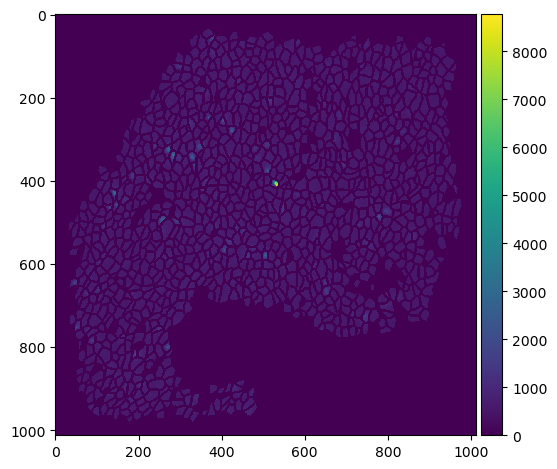

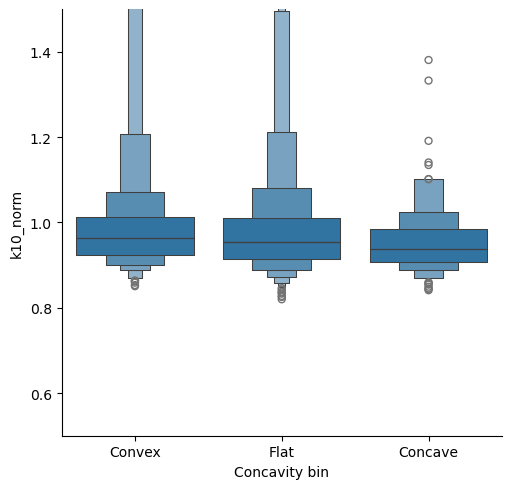

In [33]:
name = 'R2'
from skimage import filters
from imageUtils import shrink_labels

kappa = 10

flat_k10 = io.imread(dirnames[name] / 'k10_resliced.tif')
flat_k10_MIP = flat_k10[15:20,:].max(axis=0)
mask = io.imread( dirnames[name] / 'cp_masks.tif')

mask = shrink_labels(mask,border_pixels=3)

flat_k10_MIP[mask == 0] = 0
th = filters.threshold_otsu(flat_k10_MIP)
flat_k10_MIP_th = flat_k10_MIP.copy()
flat_k10_MIP_th[flat_k10_MIP_th < th] = 0
# curvature = np.load(dirnames[name] / 'mean_curvature.npz')['mean_curvature']
curvature = io.imread(dirnames[name] / f'mean_curvature_kappa{kappa}.tif')

from skimage import measure
_df = pd.DataFrame(measure.regionprops_table(mask,intensity_image = curvature,
                                            properties = ['label','area','mean_intensity']))
_df = _df.rename(columns={'mean_intensity':'curvature'})
_df = pd.merge(_df,pd.DataFrame(measure.regionprops_table(mask,intensity_image = flat_k10_MIP_th,
                                            properties = ['mean_intensity'])),
               left_index=True,right_index=True)
_df = _df.rename(columns={'mean_intensity':'k10'})
_df['k10_norm'] = _df['k10'] / _df['k10'].mean()
_df['Concavity'] = _df['curvature'] > 0
_df['Name'] = name
_df.loc[(_df['curvature'] > -0.2) & (_df['curvature'] < 0.2),'Concavity bin'] = 'Flat'
_df.loc[(_df['curvature'] > 0.2),'Concavity bin'] = 'Concave'
_df.loc[(_df['curvature'] < -0.2),'Concavity bin'] = 'Convex'
_df.to_csv(dirnames[name] / 'k10_v_curvature.csv')

io.imshow(flat_k10_MIP_th)
sb.catplot(_df,x='Concavity bin',y='k10_norm',kind='boxen',order= ['Convex','Flat','Concave'])
plt.ylim([.5,1.5])

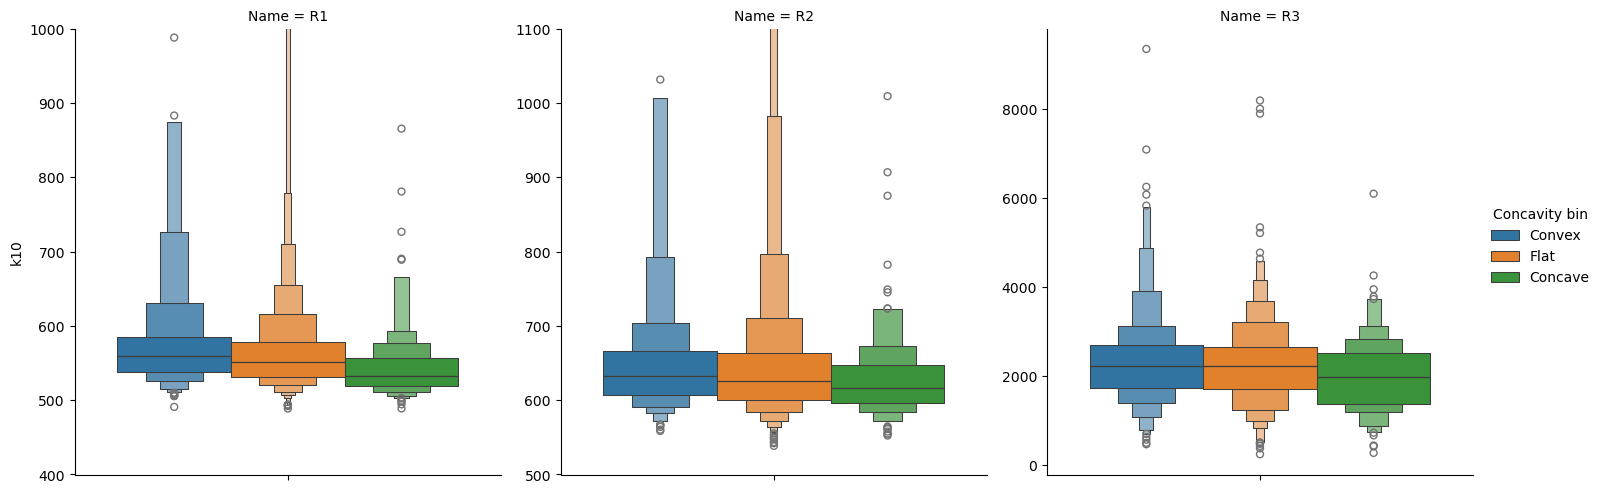

In [35]:
df = pd.concat([pd.read_csv(dirnames['R1'] /'k10_v_curvature.csv',index_col=0),
               pd.read_csv(dirnames['R2'] /'k10_v_curvature.csv',index_col=0),
               pd.read_csv(dirnames['R3'] /'k10_v_curvature.csv',index_col=0)]
         ,ignore_index=True)

df['Log-K10'] = np.log(df['k10_norm'])

g = sb.catplot(df,hue='Concavity bin',col='Name',y='k10',kind='boxen',
          hue_order=['Convex','Flat','Concave'],sharey=False)
# plt.ylim([0.5,1.5])
g.axes[0,0].set_ylim([400,1000])
g.axes[0,1].set_ylim([500,1100])

plt.savefig('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/Figures/concavity_bin_v_k10.svg')


In [36]:
from scipy.stats import ttest_ind

for mouse,_df in df.groupby('Name'):
    conv = _df.set_index('Concavity bin').loc['Convex']
    flat = _df.set_index('Concavity bin').loc['Flat']
    conc = _df.set_index('Concavity bin').loc['Concave']

    print(f'Mouse = {mouse}')
    print('Convex v. flat')
    print(ttest_ind(conv['k10_norm'],flat['k10_norm']).pvalue)
    print('Flat v. concave')
    print(ttest_ind(conc['k10_norm'],flat['k10_norm']).pvalue)
    print('Convex v. concave')
    print(ttest_ind(conv['k10_norm'],conc['k10_norm']).pvalue)

Mouse = R1
Convex v. flat
0.029332604166878253
Flat v. concave
0.04756681628392623
Convex v. concave
0.001981834773796126
Mouse = R2
Convex v. flat
0.8583322098614102
Flat v. concave
0.04891125072642649
Convex v. concave
0.008767249487703523
Mouse = R3
Convex v. flat
0.3200989462241967
Flat v. concave
0.004072623893889162
Convex v. concave
0.0009759800792729634


-0.28761650508875874
-0.20762568697418293
-0.062001138085696954


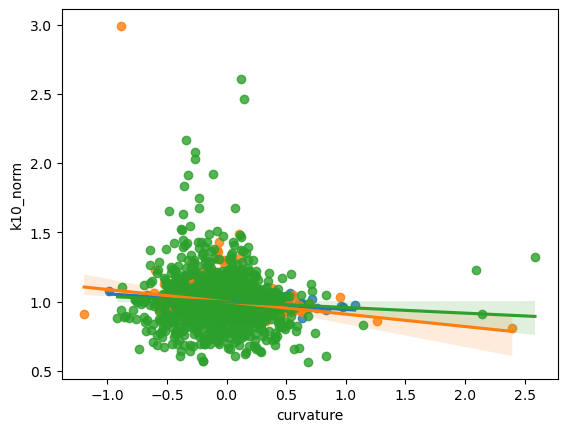

In [186]:
from basicUtils import nonan_pairs
for mouse,_df in df.groupby('Name'):
    sb.regplot(_df,x='curvature',y='k10_norm')
    X,Y = nonan_pairs(_df['curvature'],_df['k10_norm'])
    R = np.corrcoef(X,Y)
    
    print(R[0,1])
    